<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  SENTIMENT ANALYSIS OF AMAZON PRODUCT REVIEWS
</div>

<h5 style="font-weight: bold; color: black;">By : Shamila Ali C</h5>

<img src="Amazon.jpg" width="1200" style="display: block; margin: auto;">

<div style="width: 1000px; margin: 40px auto; padding: 20px; border: 1px solid #ddd; border-radius: 10px; box-shadow: 0 0 10px rgba(0, 0, 0, 0.1);">
  <div style="color: white; background-color: #FFC107; font-size: 24px; font-weight: bold; text-align: center; padding: 10px; border-radius: 5px 5px 0 0;">
    TABLE OF CONTENTS
  </div>
  <div style="padding: 20px;">
    <ol style="list-style: none; padding: 0; margin: 0;">
      <li style="margin-bottom: 10px;"><a href="#1" style="text-decoration: none; color: black; font-weight: bold;">1. Introduction</a></li>
      <li style="margin-bottom: 10px;"><a href="#2" style="text-decoration: none; color: black; font-weight: bold;">2. Import Required Dependencies</a></li>
      <li style="margin-bottom: 10px;"><a href="#3" style="text-decoration: none; color: black; font-weight: bold;">3. Data Loading</a></li>
      <li style="margin-bottom: 10px;"><a href="#4" style="text-decoration: none; color: black; font-weight: bold;">4. Descriptive Analysis</a></li>
      <li style="margin-bottom: 10px;">
        <a href="#5" style="text-decoration: none; color: black; font-weight: bold;">5. Data Understanding</a>
      </li>
      <li style="margin-bottom: 10px;"><a href="#6" style="text-decoration: none; color: black; font-weight: bold;">6. Data Cleaning and Preprocessing</a>
      </li>
      <li style="margin-bottom: 10px;"><a href="#7" style="text-decoration: none; color: black; font-weight: bold;">7. Exploratory Data Analysis (EDA)</a></li>
      <li style="margin-bottom: 10px;"><a href="#8" style="text-decoration: none; color: black; font-weight: bold;">8. Sentiment Label Creation</a>
        </li>
      <li style="margin-bottom: 10px;"><a href="#9" style="text-decoration: none; color: black; font-weight: bold;">9. Word Cloud</a></li>
      <li style="margin-bottom: 10px;"><a href="#10" style="text-decoration: none; color: black; font-weight: bold;">10. Preprocessing Text</a></li>
      <li style="margin-bottom: 10px;"><a href="#11" style="text-decoration: none; color: black; font-weight: bold;">11. TF - IDF Vectorization</a></li>
      <li style="margin-bottom: 10px;"><a href="#12" style="text-decoration: none; color: black; font-weight: bold;">12. Train - Test Split</a></li>
      <li style="margin-bottom: 10px;"><a href="#13" style="text-decoration: none; color: black; font-weight: bold;">13. Model Initialization</a></li>
      <li style="margin-bottom: 10px;"><a href="#14" style="text-decoration: none; color: black; font-weight: bold;">14. Model Building & Evaluation</a></li>
      <li style="margin-bottom: 10px;"><a href="#15" style="text-decoration: none; color: black; font-weight: bold;">15. Conclusion</a></li>

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Introduction
</div>

<h3 style="font-weight: bold; color: black;">Overview :</h3>

This project focuses on sentiment analysis of Amazon product reviews, specifically for clothing items. The dataset contains valuable information about customer demographics, product details, review text, ratings, and recommendations. By analyzing this data, we aim to identify patterns and areas for improvement to boost customer satisfaction and loyalty, ultimately helping e-commerce businesses make data-driven decisions to enhance their products and services.

<h3 style="font-weight: bold; color: black;">About the Dataset :</h3>

E-commerce (electronic commerce) is the activity of electronically buying or selling of products on online services or over the Internet. While one purchases a product, platform gives them the leverage to share the experience with their product. Through feedbacks of all kind, any platform seeks to get better and better and to satisfy their customers as best as they can. After analyzing what they rate the product as, what they write for it etc. etc. we can derive many patterns out of customers satisfaction sphere which can be taken care of in the future.

<h3 style="font-weight: bold; color: black;">Feature Description :</h3>'

<table border="1" style="border-collapse: collapse; width: 100%;">
    <tr>
        <th>Column Name</th>
        <th>Description</th>
    </tr>
    <tr><td><b>s.no</b></td><td>Simply, the Index!</td></tr>
    <tr><td><b>age</b></td><td>Age of the customer.</td></tr>
    <tr><td><b>division_name</b></td><td>Division of the Cloth customer has bought</td></tr>
    <tr><td><b>department_name</b></td><td>Department of the Cloth</td></tr>
    <tr><td><b>class_name</b></td><td>Class of the Cloth in particular.</td></tr>
    <tr><td><b>clothing_id</b></td><td>Clothing ID (Unique to a type of product).</td></tr>
    <tr><td><b>title</b></td><td>Title customers write on their feedback/review text.</td></tr>
    <tr><td><b>review_text</b></td><td>Customer's Review Text.</td></tr>
    <tr><td><b>alikefeedbackcount</b></td><td>Number of other customers who agrees with the given feedback (as their experience is quite the same).</td></tr>
    <tr><td><b>rating</b></td><td>Rating or stars they've given to the product.</td></tr>
    <tr><td><b>recommend_index</b></td><td>Whether they'll recommend someone to buy the product or not (0: NO, 1:YES)</td></tr>
</table>

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Import Required Dependencies
</div>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [5]:
from wordcloud import WordCloud

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
from sklearn.model_selection import train_test_split

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Data Loading
</div>

In [18]:
amz_df = pd.read_csv("Women Dresses Reviews Dataset .csv",encoding = "ISO-8859-1")

In [20]:
amz_df

,ï»¿s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index
0,0,40,General,Bottoms,Jeans,1028,Amazing fit and wash,Like other reviewers i was hesitant to spend t...,0,5,1
1,1,62,General Petite,Tops,Blouses,850,Lovely and unique!,As is true of a bunch of the fall clothing pho...,12,5,1
2,2,47,General Petite,Bottoms,Skirts,993,Meh,"I so wanted this skirt to work, love the desig...",3,1,0
3,3,45,General Petite,Bottoms,Pants,1068,Wow,Love love this! i was hesitant to buy this at ...,0,5,1
4,4,37,Initmates,Intimate,Swim,24,Great for bigger busts,I absolutely love the retro look of this swims...,0,5,1
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,44,General Petite,Dresses,Dresses,1081,Love it!,I oot this dress in the blue. it fits great--h...,0,5,1
23482,23482,39,General,Dresses,Dresses,1110,Great piece,I was very patient with this dress. i was wait...,1,5,1
23483,23483,29,General Petite,Tops,Knits,862,So soft and flattering,"The deep v doesn't gape, and flatters the neck...",0,5,1
23484,23484,57,General,Dresses,Dresses,1082,Another winner from isabella sinclair,"I saw this dress online this morning, went int...",10,5,1


<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Descriptive Analysis
</div>

In [23]:
amz_df.head()

,ï»¿s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index
0,0,40,General,Bottoms,Jeans,1028,Amazing fit and wash,Like other reviewers i was hesitant to spend t...,0,5,1
1,1,62,General Petite,Tops,Blouses,850,Lovely and unique!,As is true of a bunch of the fall clothing pho...,12,5,1
2,2,47,General Petite,Bottoms,Skirts,993,Meh,"I so wanted this skirt to work, love the desig...",3,1,0
3,3,45,General Petite,Bottoms,Pants,1068,Wow,Love love this! i was hesitant to buy this at ...,0,5,1
4,4,37,Initmates,Intimate,Swim,24,Great for bigger busts,I absolutely love the retro look of this swims...,0,5,1


In [25]:
amz_df.tail()

,ï»¿s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index
23481,23481,44,General Petite,Dresses,Dresses,1081,Love it!,I oot this dress in the blue. it fits great--h...,0,5,1
23482,23482,39,General,Dresses,Dresses,1110,Great piece,I was very patient with this dress. i was wait...,1,5,1
23483,23483,29,General Petite,Tops,Knits,862,So soft and flattering,"The deep v doesn't gape, and flatters the neck...",0,5,1
23484,23484,57,General,Dresses,Dresses,1082,Another winner from isabella sinclair,"I saw this dress online this morning, went int...",10,5,1
23485,23485,56,General,Jackets,Jackets,984,NaN,Super cute jacket .perfect for fall i can't st...,0,5,1


In [27]:
amz_df.sample(10)

,ï»¿s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index
16741,16741,39,General Petite,Tops,Blouses,835,True comparison,I ordered this shirt in each color and differe...,4,4,1
13271,13271,50,General Petite,Tops,Knits,866,3 colors aren't enough,I bought all 3 colors and couldn't be happier....,3,5,1
21825,21825,37,General Petite,Tops,Knits,862,NaN,"I've had my eye on this for awhile, glad it wa...",0,5,1
4012,4012,39,Initmates,Intimate,Layering,520,Ok for the price,I ordered the black (not yet available ) throu...,7,4,1
7672,7672,37,General,Tops,Blouses,818,NaN,This blouse in the purple motif is lovely. unf...,4,4,1
14107,14107,39,General,Tops,Blouses,828,Nice summer top,"I bought the color ""black motif""although the m...",2,5,1
16010,16010,37,General Petite,Tops,Knits,862,Perfect for a cool summer night,Cute and comfortable top. very cute top that i...,0,4,1
9000,9000,42,General,Bottoms,Pants,1059,Comfy,These pants run large than the true size. it i...,0,4,1
7706,7706,37,Initmates,Intimate,Lounge,377,Perfect tank!,"I know this is labeled under activewear, but t...",8,5,1
15904,15904,37,Initmates,Intimate,Intimates,645,Staple cami,This is a tts cami that should be a staple in ...,0,5,1


In [29]:
amz_df.size

258346

In [31]:
amz_df.shape

(23486, 11)

In [33]:
amz_df.columns

Index(['ï»¿s.no', 'age', 'division_name', 'department_name', 'class_name',
       'clothing_id', 'title', 'review_text', 'alike_feedback_count', 'rating',
       'recommend_index '],
      dtype='object')

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Data Understanding
</div>

<h3 style="font-weight: bold; color: black;">Data Summary</h3>

In [36]:
amz_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ï»¿s.no               23486 non-null  int64 
 1   age                   23486 non-null  int64 
 2   division_name         23472 non-null  object
 3   department_name       23472 non-null  object
 4   class_name            23472 non-null  object
 5   clothing_id           23486 non-null  int64 
 6   title                 19676 non-null  object
 7   review_text           22641 non-null  object
 8   alike_feedback_count  23486 non-null  int64 
 9   rating                23486 non-null  int64 
 10  recommend_index       23486 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


<h3 style="font-weight: bold; color: black;">Data Description</h3>

In [38]:
amz_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ï»¿s.no,23486.0,11742.500000,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
age,23486.0,43.198544,12.279544,18.0,34.00,41.0,52.00,99.0
clothing_id,23486.0,918.118709,203.298980,0.0,861.00,936.0,1078.00,1205.0
alike_feedback_count,23486.0,2.535936,5.702202,0.0,0.00,1.0,3.00,122.0
rating,23486.0,4.196032,1.110031,1.0,4.00,5.0,5.00,5.0
recommend_index,23486.0,0.822362,0.382216,0.0,1.00,1.0,1.00,1.0


<h3 style="font-weight: bold; color: black;">Checking Data Type</h3>

In [40]:
amz_df.dtypes

ï»¿s.no                  int64
age                      int64
division_name           object
department_name         object
class_name              object
clothing_id              int64
title                   object
review_text             object
alike_feedback_count     int64
rating                   int64
recommend_index          int64
dtype: object

<h3 style="font-weight: bold; color: black;">Checking Number of Unique Values</h3>

In [42]:
amz_df.nunique()

ï»¿s.no                 23486
age                        77
division_name               3
department_name             6
class_name                 20
clothing_id              1206
title                   13993
review_text             22634
alike_feedback_count       82
rating                      5
recommend_index             2
dtype: int64

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Data Cleaning and Preprocessing
</div>

<h3 style="font-weight: bold; color: black;">Renaming Column</h3>

In [45]:
amz_df.rename(columns={amz_df.columns[0]: 's.no'}, inplace=True)

In [47]:
amz_df.head()

,s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index
0,0,40,General,Bottoms,Jeans,1028,Amazing fit and wash,Like other reviewers i was hesitant to spend t...,0,5,1
1,1,62,General Petite,Tops,Blouses,850,Lovely and unique!,As is true of a bunch of the fall clothing pho...,12,5,1
2,2,47,General Petite,Bottoms,Skirts,993,Meh,"I so wanted this skirt to work, love the desig...",3,1,0
3,3,45,General Petite,Bottoms,Pants,1068,Wow,Love love this! i was hesitant to buy this at ...,0,5,1
4,4,37,Initmates,Intimate,Swim,24,Great for bigger busts,I absolutely love the retro look of this swims...,0,5,1


In [49]:
amz_df.columns

Index(['s.no', 'age', 'division_name', 'department_name', 'class_name',
       'clothing_id', 'title', 'review_text', 'alike_feedback_count', 'rating',
       'recommend_index '],
      dtype='object')

<h3 style="font-weight: bold; color: black;">Displaying Rating Value Count</h3>

In [51]:
amz_df.rating.value_counts()

rating
5    13131
4     5077
3     2871
2     1565
1      842
Name: count, dtype: int64

<h3 style="font-weight: bold; color: black;">Checking Missing Values</h3>

In [53]:
amz_df.isna().sum()

s.no                       0
age                        0
division_name             14
department_name           14
class_name                14
clothing_id                0
title                   3810
review_text              845
alike_feedback_count       0
rating                     0
recommend_index            0
dtype: int64

##### **"Null values are detected"**

<h3 style="font-weight: bold; color: black;">Handling Null Values</h3>

In [55]:
# Drop the null values from review_text column
amz_df = amz_df.dropna(subset = ['review_text'])

In [57]:
# Function to generate a simple title from review_text
def generate_title(review):
    if pd.isna(review) or review.strip() == "":
        return "No Title"  # If the review is also missing
    words = review.split()[:5]  # Take the first 5 words
    return " ".join(words)

# Apply the function to fill missing title values
amz_df['title'] = amz_df.apply(lambda row: generate_title(row['review_text']) if pd.isna(row['title']) else row['title'], axis=1)

# Check if all missing values are handled
print(amz_df['title'].isnull().sum())  

0


In [59]:
# Filling the missing values with Mode for categorical features
amz_df['division_name'] = amz_df['division_name'].fillna(amz_df['division_name'].mode()[0])
amz_df['department_name'] = amz_df['department_name'].fillna(amz_df['department_name'].mode()[0])
amz_df['class_name'] = amz_df['class_name'].fillna(amz_df['class_name'].mode()[0])

In [61]:
amz_df.isnull().sum()

s.no                    0
age                     0
division_name           0
department_name         0
class_name              0
clothing_id             0
title                   0
review_text             0
alike_feedback_count    0
rating                  0
recommend_index         0
dtype: int64

##### **"Null values handled successfully"**

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Exploratory Data Analysis (EDA)
</div>

<h3 style="font-weight: bold; color: black;">Age Distribution</h3>

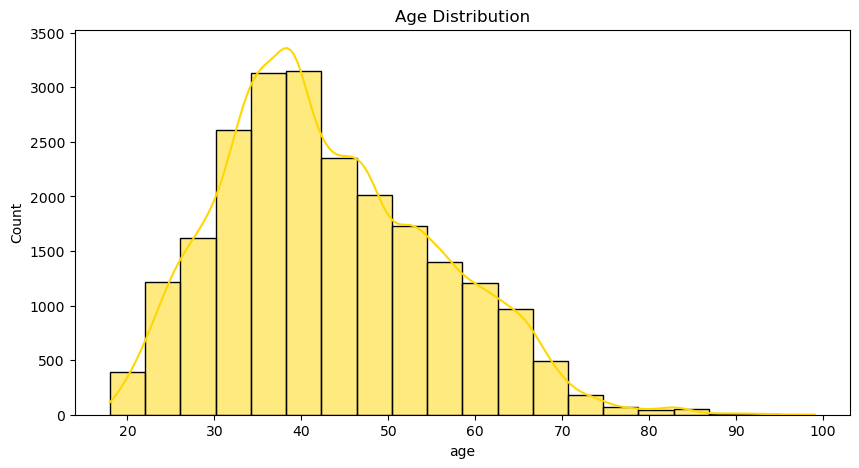

In [279]:
plt.figure(figsize=(10,5))
sns.histplot(amz_df['age'], bins =20, kde =True, color='#FFD700')
plt.title('Age Distribution')
plt.show()

* The age distribution is roughly bell-shaped, skewed slightly to the right.
* Most of the data points are concentrated between ages 20 and 60.
* The peak age range is around 35-40 years.
* There's a gradual decline in count as age increases beyond 40.
* Very few data points are above 70 years, with almost none above 90 years.

<h3 style="font-weight: bold; color: black;">Most Reviewed Clothing Categories</h3>

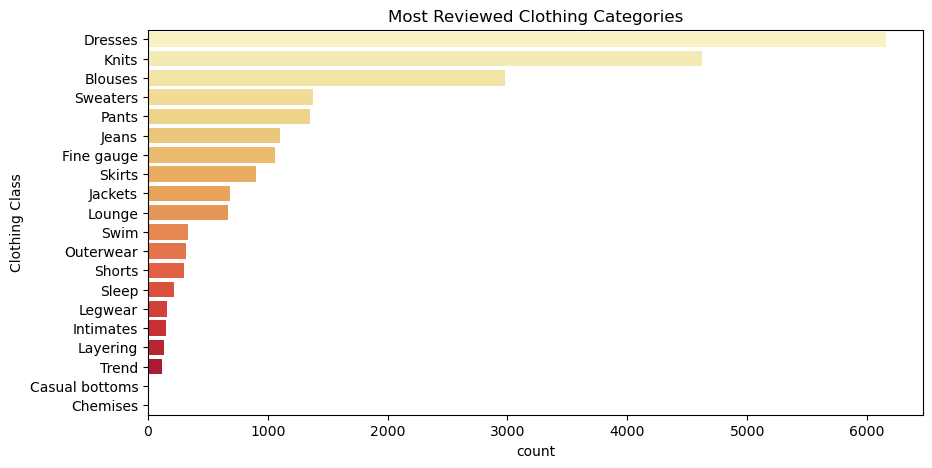

In [274]:
plt.figure(figsize=(10,5))
sns.countplot(y = amz_df['class_name'], order=amz_df['class_name'].value_counts().index,
             palette ='YlOrRd')
plt.title('Most Reviewed Clothing Categories')
plt.ylabel('Clothing Class')
plt.show()

* Top reviewed category: Dresses (6000 reviews)
* Followed by: Knits (4500 reviews) and Blouses (4000 reviews)
* Least reviewed categories: Chemises, Casual bottoms, and Trend
* Dresses are significantly more reviewed than other categories

<h3 style="font-weight: bold; color: black;">Rating Distribution</h3>

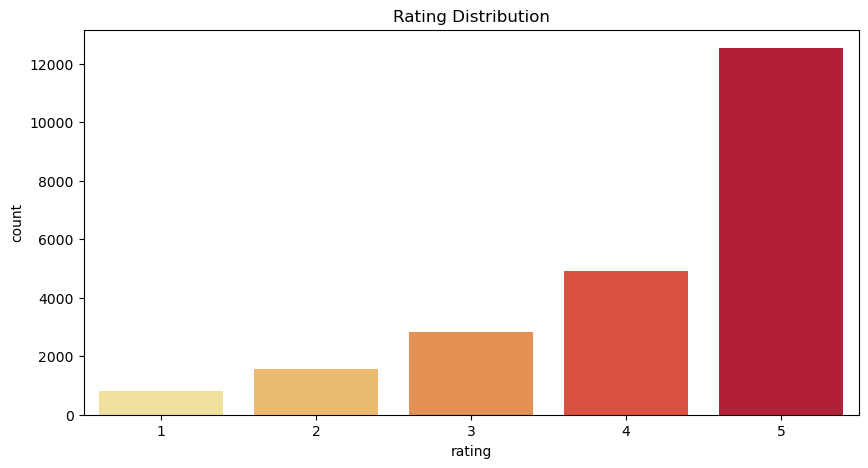

In [285]:
plt.figure(figsize=(10,5))
sns.countplot(x=amz_df['rating'], palette='YlOrRd')
plt.title('Rating Distribution')
plt.show()

* Most ratings are 5 (around 12000 counts), indicating a high overall satisfaction.
* Ratings decrease as the rating value decreases (from 5 to 1).
* The count of ratings for 1 is the lowest.
* The distribution suggests a skewed preference towards higher ratings (4 and 5).

<h3 style="font-weight: bold; color: black;">Most Reviewed Departments</h3>

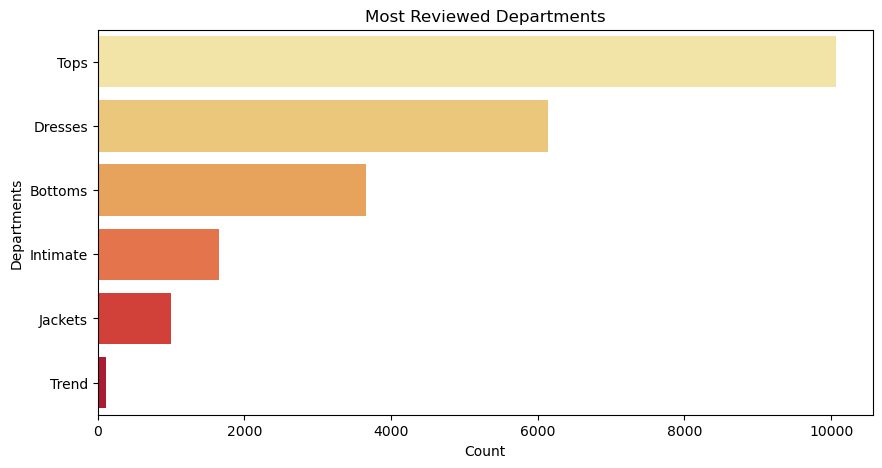

In [287]:
plt.figure(figsize=(10,5))
sns.countplot(y=amz_df['department_name'],
              order= amz_df['department_name'].value_counts().index, palette='YlOrRd')
plt.title('Most Reviewed Departments')
plt.xlabel('Count')
plt.ylabel('Departments')
plt.show()

* Tops has the highest number of reviews (~10,000).
* Dresses is second with around 6,000 reviews.
* Bottoms, Intimate, Jackets, and Trend follow in that order with decreasing review counts.
* Trend has the least number of reviews, barely visible on the chart.

<h3 style="font-weight: bold; color: black;">Most Reviewed Divisions</h3>

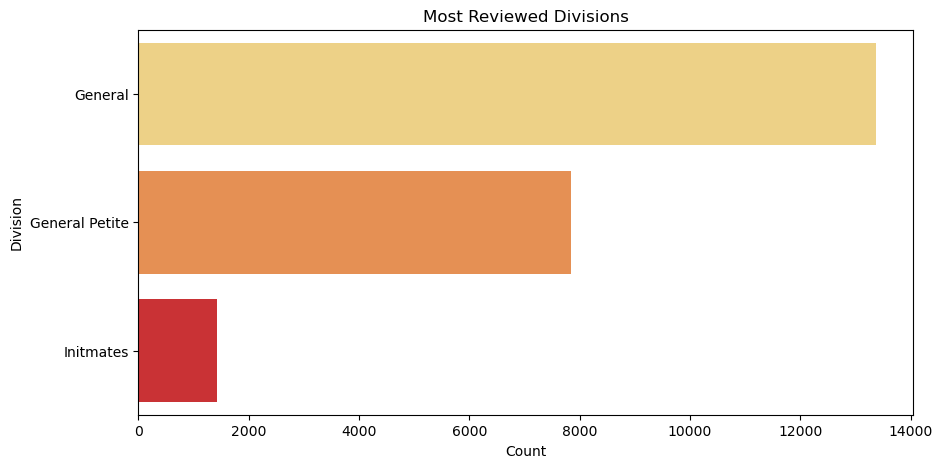

In [289]:
plt.figure(figsize=(10,5))
sns.countplot(y=amz_df['division_name'],
              order= amz_df['division_name'].value_counts().index, palette='YlOrRd')
plt.title('Most Reviewed Divisions')
plt.xlabel('Count')
plt.ylabel('Division')
plt.show()

* General has the highest count, around 13,000 reviews.
* General Petite has around 7,000 reviews.
* Initmates has the lowest count, around 1,000 reviews.

<h3 style="font-weight: bold; color: black;">Top 10 Clothing Categories with Most Ratings</h3>

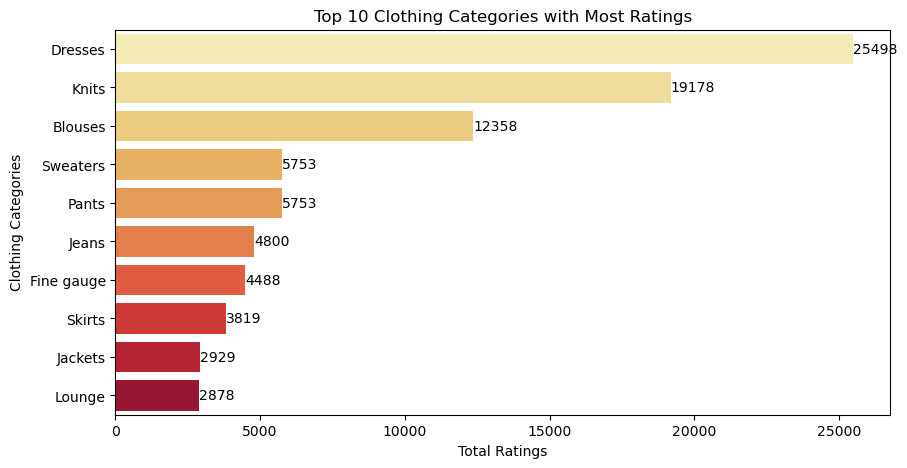

In [291]:
# Get total ratings and rating counts for each category
top_categories = amz_df.groupby('class_name')['rating'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(10)

plt.figure(figsize=(10,5))

# Plotting total ratings for each category
sns.barplot(x=top_categories['sum'], y=top_categories.index, palette='YlOrRd')

# Adding labels for the ratings next to each bar
for index, value in enumerate(top_categories['sum']):
    plt.text(value, index, f'{value}', color='black', ha="left", va="center")

plt.title('Top 10 Clothing Categories with Most Ratings')
plt.xlabel('Total Ratings')
plt.ylabel('Clothing Categories')
plt.show()

* Top category: Dresses have the most ratings (25,498).
* Second and third: Knits (19,178) and Blouses (12,358) follow.
* Tied categories: Sweaters and Pants both have 5,753 ratings.
* Least in top 10: Lounge has the least ratings (2,878) among the top 10 categories.

<h3 style="font-weight: bold; color: black;">Recommendation Percentage</h3>

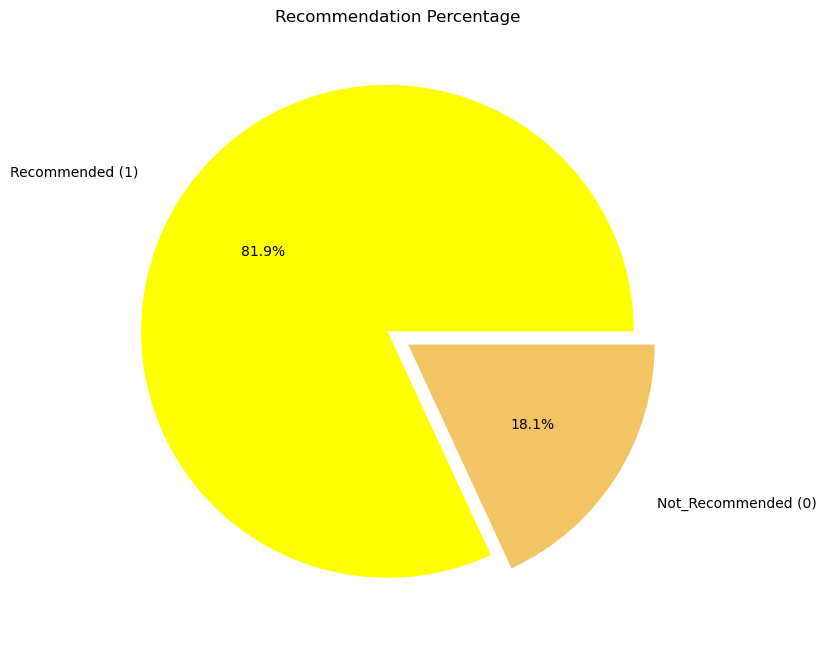

In [295]:
explode = (0.05, 0.05)

plt.figure(figsize=(8,8))

labels = ['Recommended (1)', 'Not_Recommended (0)']
sizes = amz_df['recommend_index '].value_counts()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#FFFF00', '#F2C464'], explode = explode, labeldistance=1.2)
plt.title('Recommendation Percentage')
plt.show()

* Recommended: 81.9%
* Not Recommended: 18.1%
* Majority of the recommendations are positive (Recommended).

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Sentiment Label Creation
</div>

In [79]:
# Sentiment label creation
def label_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

In [81]:
amz_df['sentiment'] = amz_df['rating'].apply(label_sentiment)

In [83]:
amz_df.head()

,s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index,sentiment
0,0,40,General,Bottoms,Jeans,1028,Amazing fit and wash,Like other reviewers i was hesitant to spend t...,0,5,1,positive
1,1,62,General Petite,Tops,Blouses,850,Lovely and unique!,As is true of a bunch of the fall clothing pho...,12,5,1,positive
2,2,47,General Petite,Bottoms,Skirts,993,Meh,"I so wanted this skirt to work, love the desig...",3,1,0,negative
3,3,45,General Petite,Bottoms,Pants,1068,Wow,Love love this! i was hesitant to buy this at ...,0,5,1,positive
4,4,37,Initmates,Intimate,Swim,24,Great for bigger busts,I absolutely love the retro look of this swims...,0,5,1,positive


In [85]:
amz_df.columns

Index(['s.no', 'age', 'division_name', 'department_name', 'class_name',
       'clothing_id', 'title', 'review_text', 'alike_feedback_count', 'rating',
       'recommend_index ', 'sentiment'],
      dtype='object')

<h3 style="font-weight: bold; color: black;">Sentiment Count</h3>

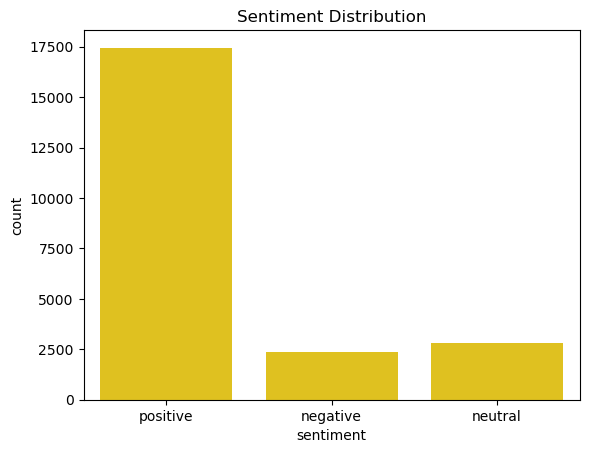

In [297]:
sns.countplot(data=amz_df, x='sentiment',color='#FFD700')
plt.title("Sentiment Distribution")
plt.show()

* The positive sentiment has the highest count, close to 17500.
* Negative sentiment has the lowest count, around 2500.
* Neutral sentiment is slightly higher than negative, also around 2500-3000.

<h3 style="font-weight: bold; color: black;">Sentiment Value Count</h3>

In [89]:
amz_df.sentiment.value_counts()

sentiment
positive    17448
neutral      2823
negative     2370
Name: count, dtype: int64

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Word Cloud
</div>

In [133]:
def color_func(*args, **kwargs):
    return random.choice(["blue"])

In [299]:
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, colormap='YlOrBr', background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

<h3 style="font-weight: bold; color: black;">Positive Reviews</h3>

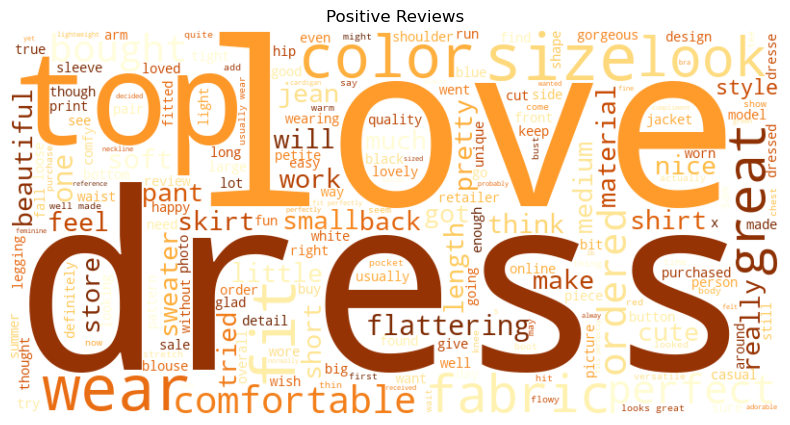

In [302]:
generate_wordcloud(amz_df[amz_df['sentiment']=='positive']['review_text'], "Positive Reviews")

<h3 style="font-weight: bold; color: black;">Neutral Reviews</h3>

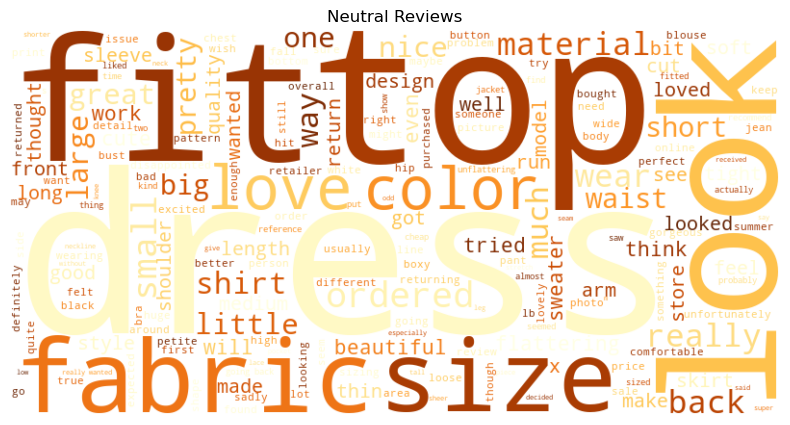

In [305]:
generate_wordcloud(amz_df[amz_df['sentiment']=='neutral']['review_text'], "Neutral Reviews")

<h3 style="font-weight: bold; color: black;">Negative Reviews</h3>

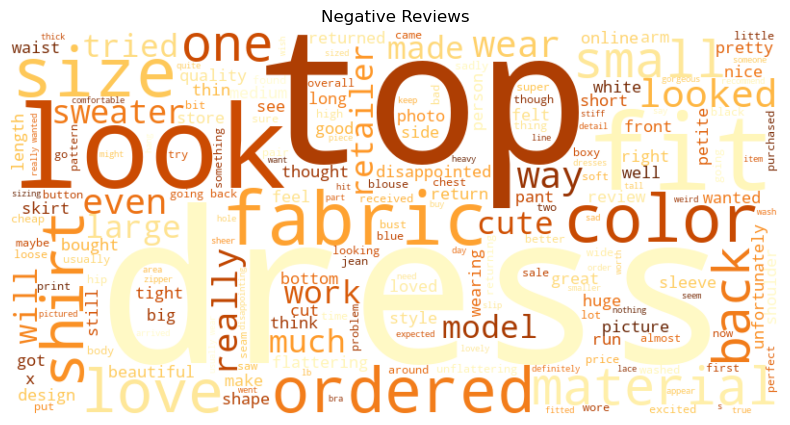

In [308]:
generate_wordcloud(amz_df[amz_df['sentiment']=='negative']['review_text'], "Negative Reviews")

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Preprocessing Text
</div>

In [147]:
# Lowercase, remove punctuation, digits, and stopwords
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [149]:
def wordopt(review_text): #creating function to process text
    text=text.lower()
    text=re.sub('\[.*?\]','',review_text)
    text=re.sub("\\W"," ",review_text)
    text=re.sub('https?://\S+|www\.\S+','',review_text)
    text=re.sub('<.*?>+','',review_text)
    text=re.sub('[%s]'% re.escape(string.punctuation),'',review_text)
    text=re.sub('\n','',review_text)
    text=re.sub('\w*\d\w*','',review_text)
    return review_text

In [151]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [153]:
amz_df['clean_text'] = amz_df['review_text'].astype(str).apply(clean_text)

In [155]:
amz_df.head()

,s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index,sentiment,clean_text
0,0,40,General,Bottoms,Jeans,1028,Amazing fit and wash,Like other reviewers i was hesitant to spend t...,0,5,1,positive,like reviewer hesitant spend much pair jean ho...
1,1,62,General Petite,Tops,Blouses,850,Lovely and unique!,As is true of a bunch of the fall clothing pho...,12,5,1,positive,true bunch fall clothing photo color totally w...
2,2,47,General Petite,Bottoms,Skirts,993,Meh,"I so wanted this skirt to work, love the desig...",3,1,0,negative,wanted skirt work love design way way long lb ...
3,3,45,General Petite,Bottoms,Pants,1068,Wow,Love love this! i was hesitant to buy this at ...,0,5,1,positive,love love hesitant buy first review made seem ...
4,4,37,Initmates,Intimate,Swim,24,Great for bigger busts,I absolutely love the retro look of this swims...,0,5,1,positive,absolutely love retro look swimsuit first saw ...


<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  TF - IDF Vectorization
</div>

In [158]:
# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(amz_df['clean_text'])

In [160]:
X

<22641x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 575124 stored elements in Compressed Sparse Row format>

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Train - Test Split
</div>

In [162]:
# Target labels
y = amz_df['sentiment']

In [164]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Model Initialization
</div>

In [167]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVC": SVC(),
    "Multinomial NB": MultinomialNB(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "Extra Trees": ExtraTreesClassifier()
}

In [169]:
results = {}

<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Model Building & Evaluation
</div>

In [172]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))


Logistic Regression Accuracy: 0.8218
              precision    recall  f1-score   support

    negative       0.62      0.40      0.49       488
     neutral       0.42      0.23      0.30       545
    positive       0.87      0.97      0.92      3496

    accuracy                           0.82      4529
   macro avg       0.64      0.54      0.57      4529
weighted avg       0.79      0.82      0.80      4529


Random Forest Accuracy: 0.7885
              precision    recall  f1-score   support

    negative       0.70      0.15      0.25       488
     neutral       0.53      0.02      0.03       545
    positive       0.79      1.00      0.88      3496

    accuracy                           0.79      4529
   macro avg       0.67      0.39      0.39      4529
weighted avg       0.75      0.79      0.71      4529


Decision Tree Accuracy: 0.7189
              precision    recall  f1-score   support

    negative       0.31      0.31      0.31       488
     neutral       0.23    

<h3 style="font-weight: bold; color: black;">Model Performance Summary</h3>

In [228]:
summary_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
summary_df = summary_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
summary_df

,Model,Accuracy
0,Logistic Regression,0.821815
1,SVC,0.816957
2,AdaBoost,0.799293
3,Gradient Boosting,0.797969
4,Random Forest,0.788474
5,Extra Trees,0.785383
6,Bagging,0.783617
7,KNN,0.781629
8,Multinomial NB,0.779863
9,Decision Tree,0.718922


<div style="color: white; background-color: #FFC107; font-size: 28px; font-weight: bold; text-align: center; padding: 10px 20px; border-radius: 20px;">
  Conclusion
</div>

* This project analyzed **23,486 Amazon product reviews** to determine customer sentiment using **Natural Language Processing (NLP)**.
* **Exploratory Data Analysis (EDA)** and **word clouds** revealed that the dataset was **heavily skewed toward positive reviews**, with common positive terms such as **love, fit, and comfortable**, while negative reviews focused on **size and quality** issues.
* Several machine learning models were trained, including Logistic Regression, Random Forest, Naive Bayes, SVM, Decision Tree, and Gradient Boosting. * * **Logistic Regression** achieved the best **accuracy** of **82.18%**.
* Customers generally satisfied — **strong positive sentiment**.
* **Negative** feedback mostly about **size and quality**.
* However, performance on **neutral** and **negative** sentiments is **lower due to imbalance**.